<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/nevets/progress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, OPTICS, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import plotly.graph_objs as go

# **Data Loading**


In [4]:
df = pd.read_excel('Online Retail.xlsx')

In [5]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## **Exploratory Data Analysis (EDA)**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


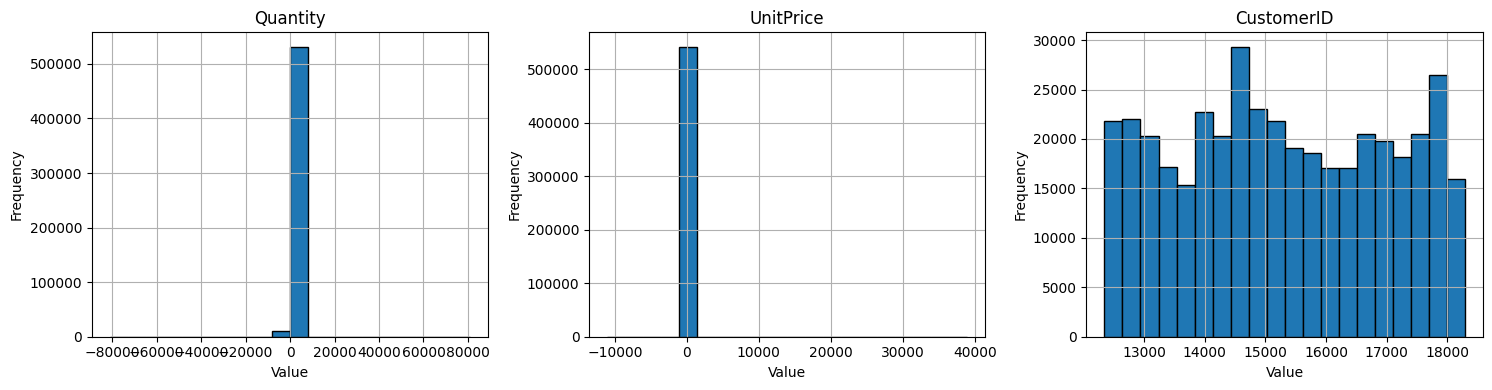

In [8]:
# Menampilkan Bar Chart untuk setiap kolom pada data
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

num_vars = df[numerical_cols].shape[1]

n_cols = 4
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

axes = axes.flatten()

for i, column in enumerate(df[numerical_cols].columns):
    df[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

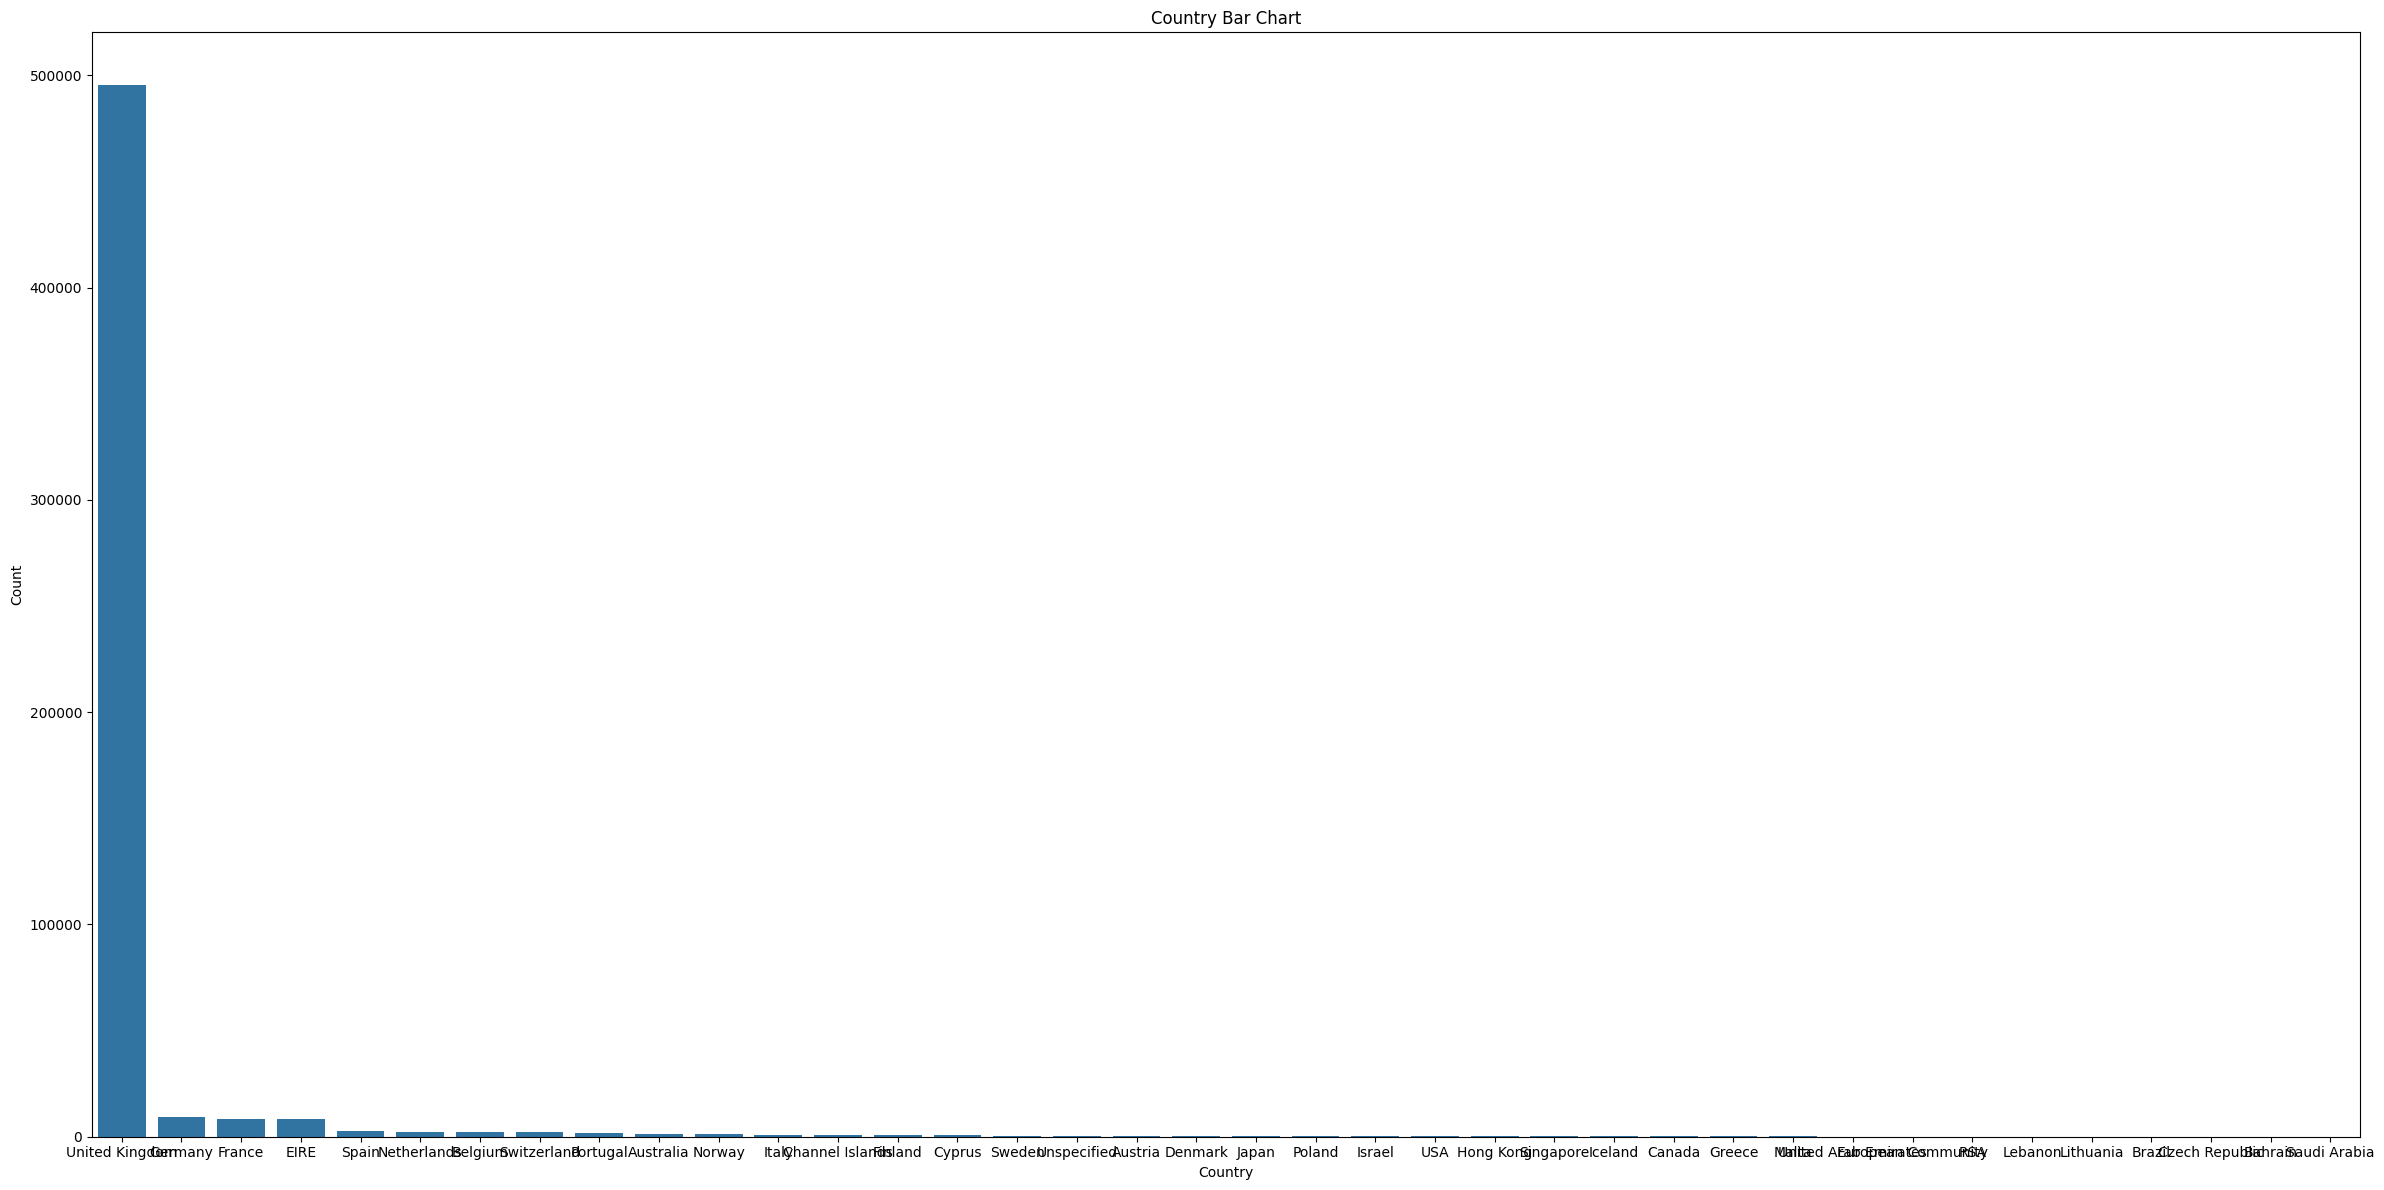

In [9]:
country = df['Country'].value_counts()

plt.figure(figsize=(24, 12))

sns.barplot(x=country.index, y=country.values)
plt.title('Country Bar Chart')
plt.xlabel('Country')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [10]:
df_lencoder = df.copy()

for column in df_lencoder[categorical_cols].columns:
    label_encoder = LabelEncoder()
    df_lencoder[column] = label_encoder.fit_transform(df_lencoder[column].astype(str))

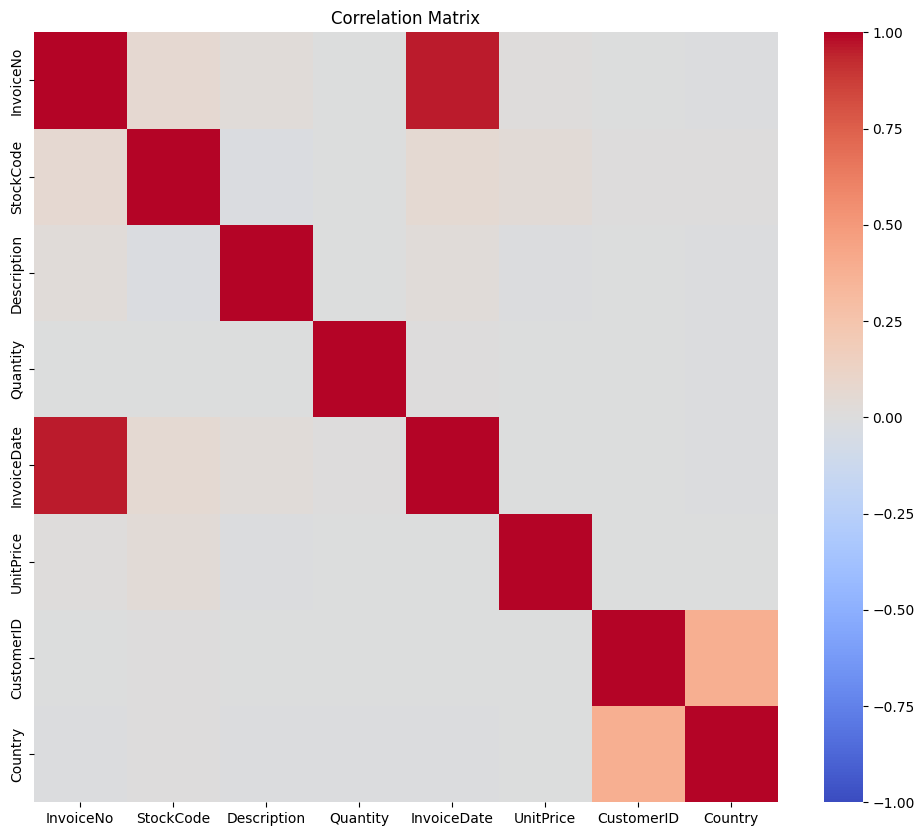

In [11]:
# Menampilkan Heatmap korelasi antar data
plt.figure(figsize=(12, 10))
correlation_matrix = df_lencoder.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

# **Pre-processing**

## Raw Data

In [12]:
df.duplicated().sum()

np.int64(5268)

In [13]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [14]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


In [15]:
df.dropna(inplace=True)
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [16]:
min_date = df['InvoiceDate'].min()
df[df['InvoiceDate'] == min_date]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom


In [17]:
start_date = "2011-01-01 00:00:00"

df.drop(df[df['InvoiceDate'] < start_date].index, inplace=True)

min_date = df['InvoiceDate'].min()
df[df['InvoiceDate'] == min_date]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
42481,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom
42482,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
42483,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
42484,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom
42485,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom
42486,539993,85099B,JUMBO BAG RED RETROSPOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom
42487,539993,20682,RED RETROSPOT CHILDRENS UMBRELLA,6,2011-01-04 10:00:00,3.25,13313.0,United Kingdom
42488,539993,22961,JAM MAKING SET PRINTED,12,2011-01-04 10:00:00,1.45,13313.0,United Kingdom
42489,539993,22667,RECIPE BOX RETROSPOT,6,2011-01-04 10:00:00,2.95,13313.0,United Kingdom
42490,539993,22898,CHILDRENS APRON APPLES DESIGN,8,2011-01-04 10:00:00,1.95,13313.0,United Kingdom


In [18]:
df.drop(df[df['Country'] != 'United Kingdom'].index, inplace=True)

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
42481,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom
42482,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
42483,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom
42484,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom
42485,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom
...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom


### Sistem Rekomendasi


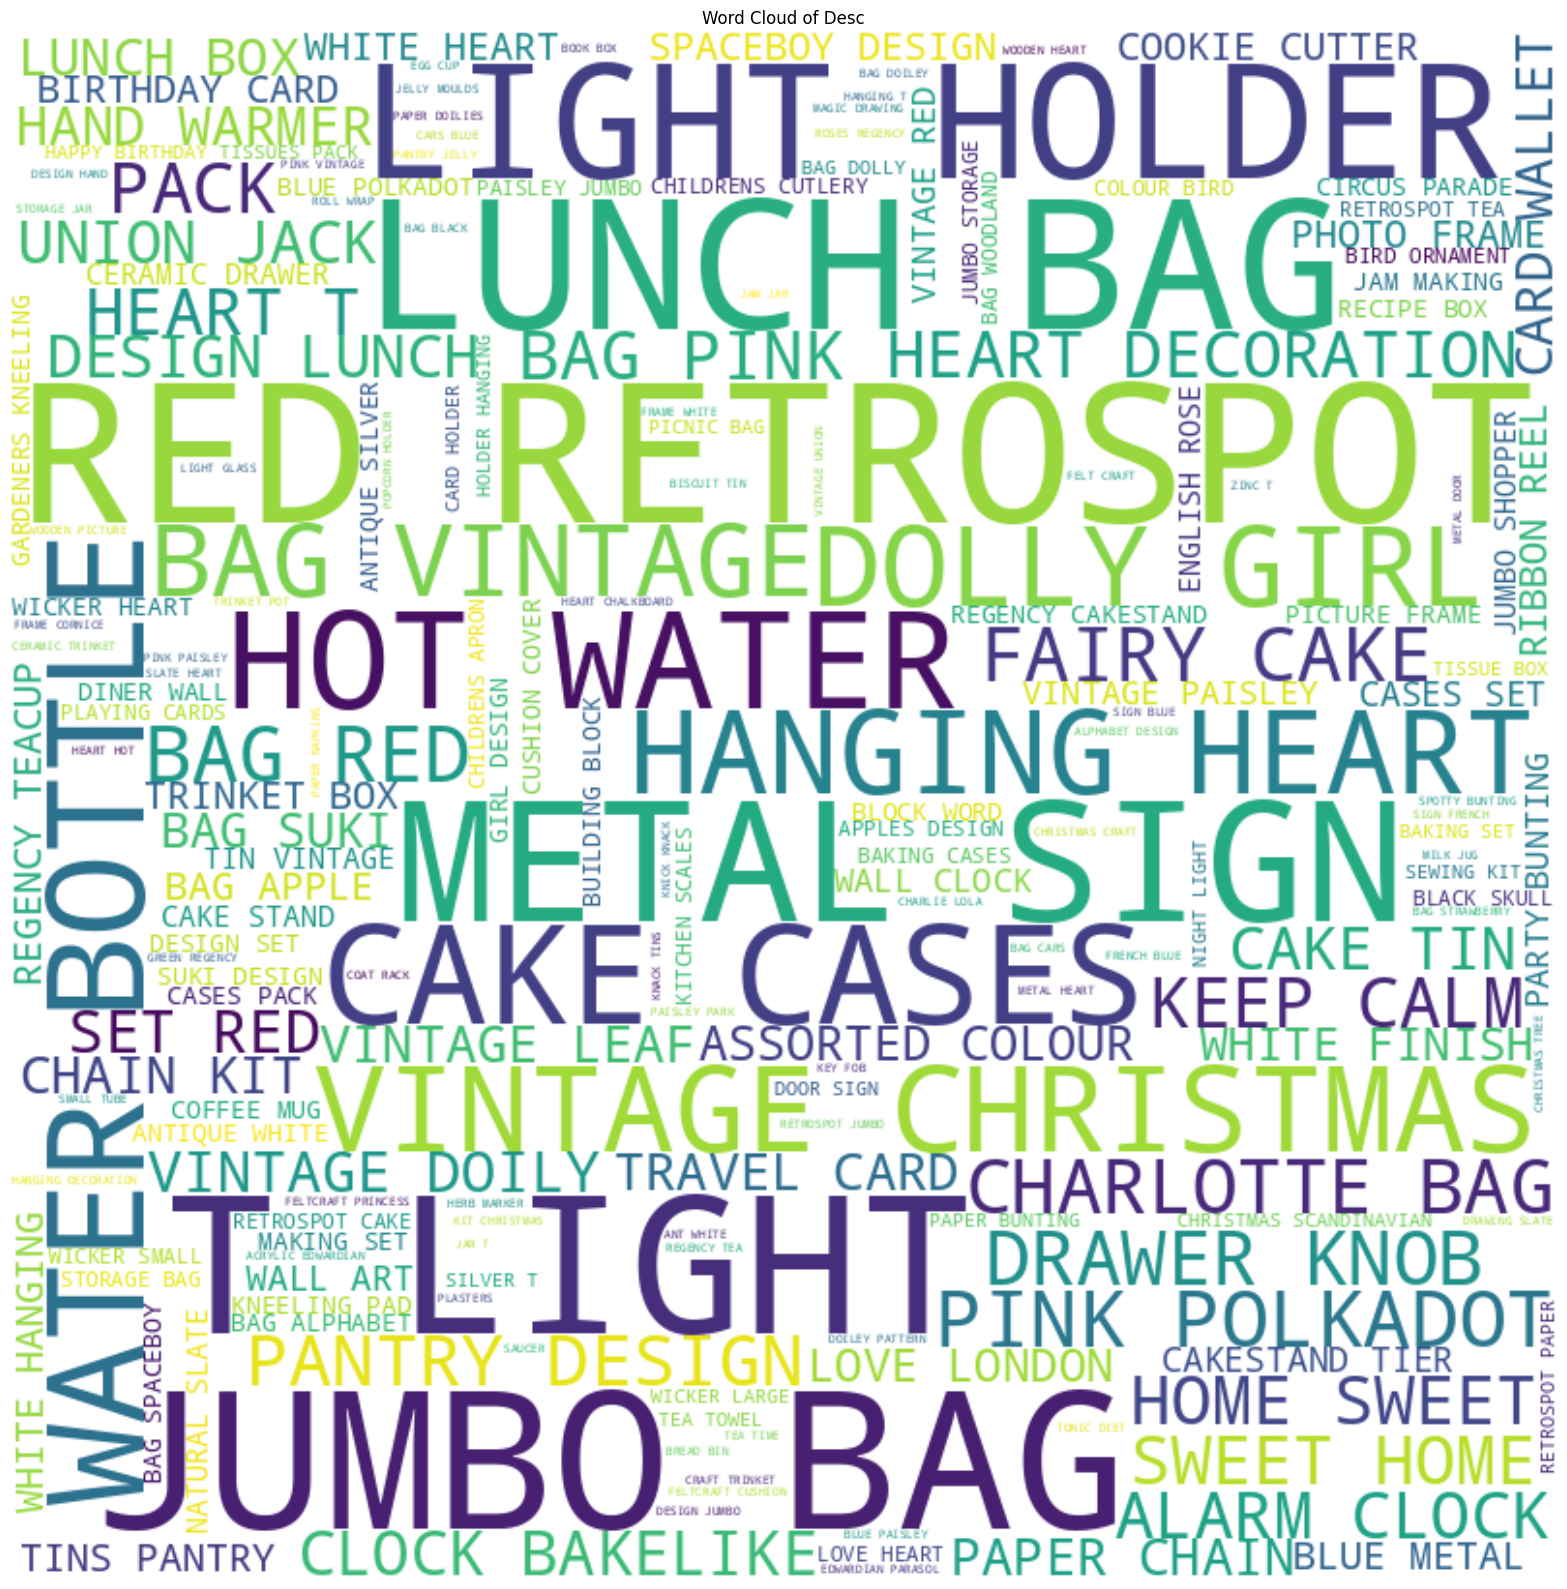

In [19]:
list_text = ' '.join(df['Description'])
wc = WordCloud(width=800, height=800, background_color='white').generate(list_text)

fig, ax = plt.subplots(1, 1, figsize=(16, 16))

ax.imshow(wc, interpolation='bilinear')
ax.set_title(f'Word Cloud of Desc')
ax.axis('off')

plt.tight_layout()
plt.show()

In [20]:
dict_category = {
    'bags': [
        'bag', 'shopper', 'tote', 'lunch', 'jumbo bag',
        'satchel', 'handbag', 'travel bag'
    ],

    'kitchen': [
        'mug', 'cup', 'teacup', 'plate', 'bowl', 'dish',
        'bottle', 'water bottle', 'pantry', 'jug', 'milk jug',
        'teapot', 'napkin', 'coaster', 'tray', 'cutlery',
        'bread bin', 'egg cup', 'salt', 'pepper', 'kitchen'
    ],

    'decoration': [
        'heart', 'hanging', 'ornament', 'frame', 'photo frame',
        'sign', 'door sign', 'wall art', 'decoration',
        'doorstop', 'cushion', 'mirror', 'vase', 'bunting',
        'union jack', 'sweet home', 'love'
    ],

    'lighting': [
        'light', 't light', 'tlight', 'lantern', 'candle',
        'lamp', 'led', 'night light', 'fairy light', 'tea light'
    ],

    'christmas': [
        'christmas', 'xmas', 'santa', 'snowman', 'reindeer',
        'advent', 'stocking', 'tree decoration', 'bauble'
    ],

    'storage': [
        'box', 'tin', 'jar', 'basket', 'case', 'cases',
        'container', 'storage', 'trinket', 'recipe box',
        'tissue box', 'book box', 'chest'
    ],

    'baking': [
        'cake', 'cakestand', 'cake stand', 'baking', 'cookie',
        'mould', 'fairy cake', 'cupcake', 'muffin', 'recipe'
    ],

    'stationery': [
        'card', 'birthday', 'notebook', 'paper', 'wrap',
        'ribbon', 'tag', 'pen', 'pencil', 'gift'
    ],

    'clocks': [
        'clock', 'alarm', 'wall clock', 'alarm clock', 'watch'
    ],

    'garden': [
        'garden', 'plant', 'pot', 'flower', 'seed',
        'herb', 'watering', 'bird'
    ],

    'kids': [
        'spaceboy', 'dolly', 'fairy', 'childrens', 'children',
        'kids', 'girl', 'boy', 'toy', 'doll', 'teddy', 'baby'
    ],

    'furniture': [
        'drawer', 'knob', 'handle', 'hook', 'hanger',
        'coat', 'door', 'cabinet'
    ]
}

def category_map(desc):
    desc = str(desc).lower()

    for category, keywords in dict_category.items():
        for item in keywords:
            if item in desc:
                return category
    return 'others'

In [21]:
df['category'] = df['Description'].apply(category_map)

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,category
42481,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom,bags
42482,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,stationery
42483,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,stationery
42484,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom,bags
42485,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom,bags
...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,lighting
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,decoration
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,decoration
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,storage


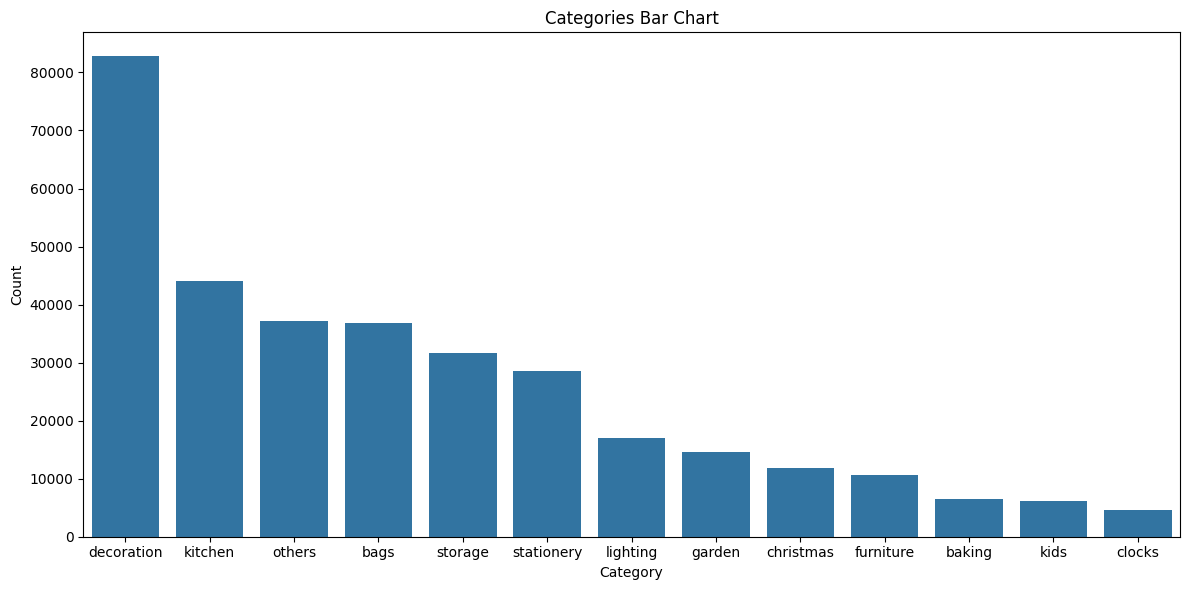

In [22]:
categories = df['category'].value_counts()

plt.figure(figsize=(12, 6))

sns.barplot(x=categories.index, y=categories.values)
plt.title('Categories Bar Chart')
plt.xlabel('Category')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [23]:
df['Sales'] = df['Quantity'] * df['UnitPrice']
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,category,Sales
42481,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom,bags,19.5
42482,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,stationery,10.5
42483,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,stationery,10.5
42484,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom,bags,10.5
42485,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom,bags,12.5
...,...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,lighting,23.4
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,decoration,23.6
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,decoration,30.0
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,storage,214.8


## RFM

In [72]:
from os.path import join
Recency = ('InvoiceDate', lambda x: (analysis_date - x.max()).days)
Frequency = ('InvoiceNo', 'nunique')
Monetary = ('Sales', 'sum')


In [73]:
df_rfm = df.groupby('CustomerID').agg(
  Recency=Recency,
  Frequency=Frequency,
  Monetary=Monetary
).reset_index()

df_rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12747.0,2,9,3489.74
2,12748.0,1,187,24271.01
3,12749.0,4,8,3868.20
4,12820.0,3,4,942.34
...,...,...,...,...
3830,18280.0,278,1,180.60
3831,18281.0,181,1,80.82
3832,18282.0,8,3,176.60
3833,18283.0,4,16,2045.53


In [26]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3835 entries, 0 to 3834
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  3835 non-null   float64
 1   Recency     3835 non-null   int64  
 2   Frequency   3835 non-null   int64  
 3   Monetary    3835 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 120.0 KB


In [27]:
df_rfm.describe(include='all')

,CustomerID,Recency,Frequency,Monetary
count,3835.000000,3835.000000,3835.000000,3835.000000
mean,15550.676662,83.572881,4.767927,1633.762953
std,1575.054051,89.626572,8.020472,6150.531756
min,12346.000000,1.000000,1.000000,-4287.630000
25%,14197.000000,16.000000,1.000000,275.730000
50%,15556.000000,46.000000,3.000000,613.950000
75%,16905.500000,127.000000,5.000000,1488.640000
max,18287.000000,340.000000,187.000000,228603.880000


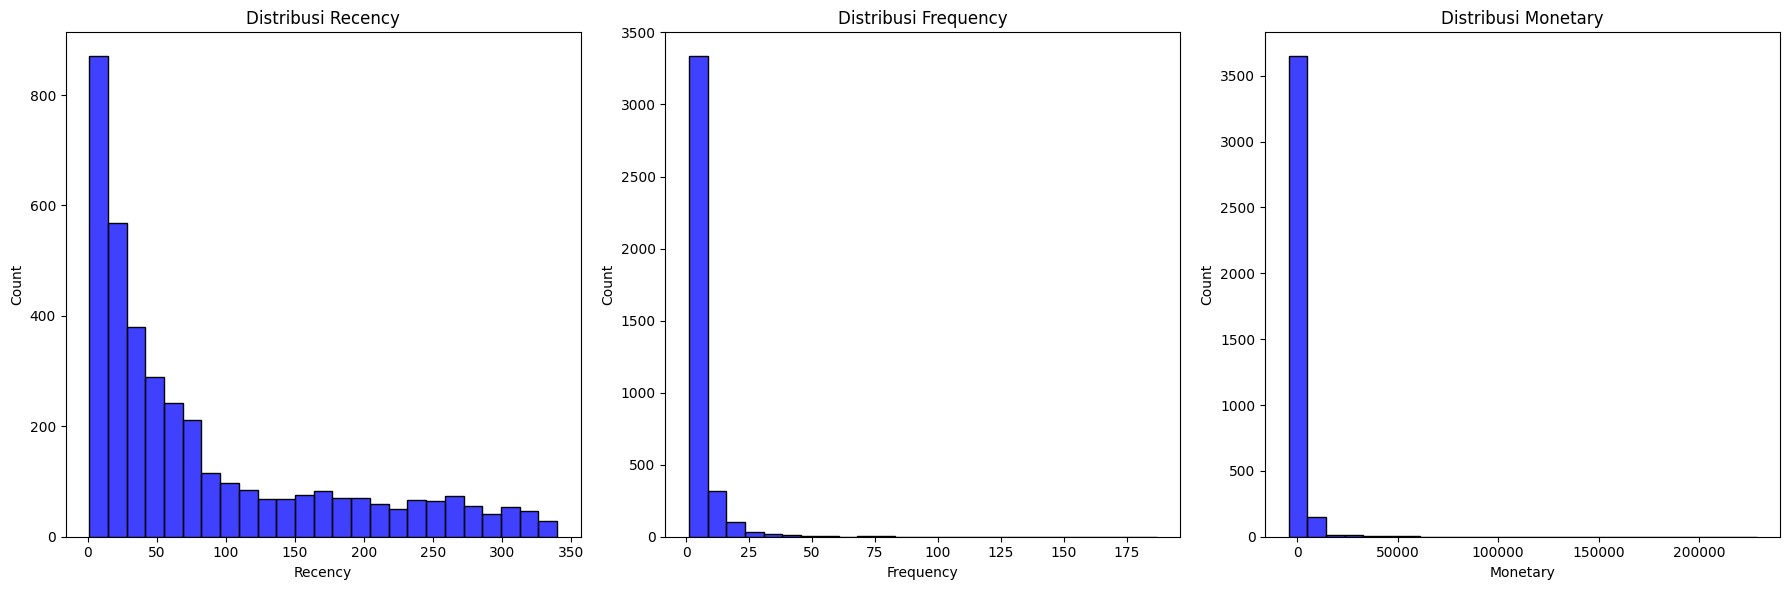

In [28]:
columns = ['Recency', 'Frequency', 'Monetary']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, column in enumerate(columns):
  sns.histplot(df_rfm[column], bins=25, color='blue', ax=axes[i])
  axes[i].set_title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

In [29]:
df_rfm_clean = df_rfm.copy()
df_rfm_clean = df_rfm_clean[df_rfm_clean['Monetary'] > 0]

df_rfm_clean.describe(include='all')

,CustomerID,Recency,Frequency,Monetary
count,3798.000000,3798.000000,3798.000000,3.798000e+03
mean,15551.069510,82.789363,4.797262,1.652564e+03
std,1574.445634,89.092252,8.053186,6.177014e+03
min,12747.000000,1.000000,1.000000,1.776357e-15
25%,14196.500000,16.000000,1.000000,2.855425e+02
50%,15553.500000,45.000000,3.000000,6.232200e+02
75%,16906.750000,124.000000,5.000000,1.504487e+03
max,18287.000000,340.000000,187.000000,2.286039e+05


In [30]:
df_rfm_log = df_rfm_clean.copy()
df_rfm_log[columns] = np.log1p(df_rfm_log[columns])

df_rfm_log.head()

,CustomerID,Recency,Frequency,Monetary
1,12747.0,1.098612,2.302585,8.157869
2,12748.0,0.693147,5.236442,10.097079
3,12749.0,1.609438,2.197225,8.260803
4,12820.0,1.386294,1.609438,6.849427
5,12821.0,5.370638,0.693147,4.540312


In [31]:
df_rfm_scaled = df_rfm_log.copy()

scaler = RobustScaler()
df_rfm_scaled[columns] = scaler.fit_transform(df_rfm_scaled[columns])

df_rfm_scaled.head()

,CustomerID,Recency,Frequency,Monetary
1,12747.0,-1.368367,0.834044,1.037602
2,12748.0,-1.571597,3.504555,2.206515
3,12749.0,-1.112327,0.738140,1.099648
4,12820.0,-1.224172,0.203114,0.248901
5,12821.0,0.772892,-0.630930,-1.142983


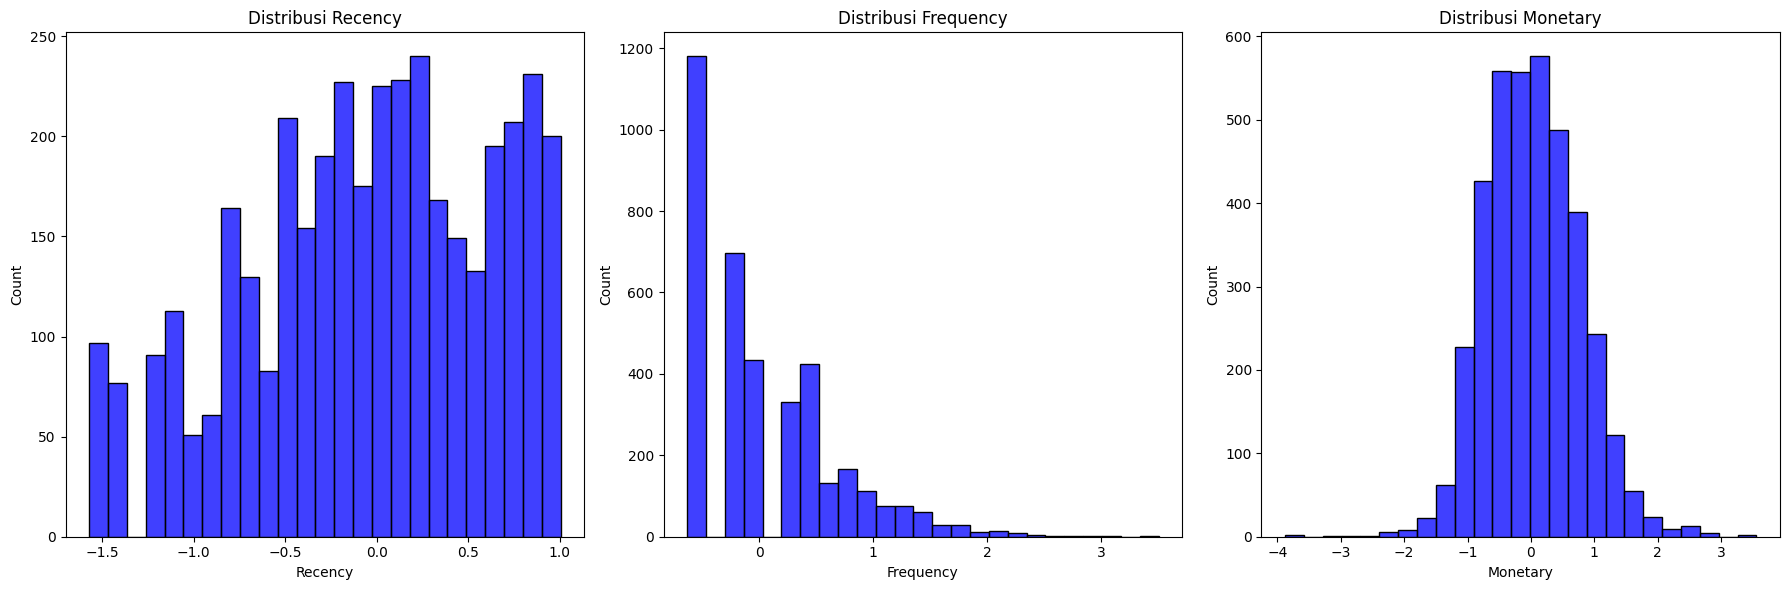

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, column in enumerate(columns):
  sns.histplot(df_rfm_scaled[column], bins=25, color='blue', ax=axes[i])
  axes[i].set_title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

In [33]:
bin_columns = ['Recency', 'FrequencyBin', 'Monetary']
bins = [-np.inf, 0, 1, 2, np.inf]
bin_labels = ['Low', 'Medium', 'High', 'Very High']

df_rfm_binned = df_rfm_scaled.copy()
df_rfm_binned['FrequencyBin'] = pd.cut(df_rfm_binned['Frequency'], bins=bins, labels=bin_labels)

le = LabelEncoder()
df_rfm_binned['FrequencyBin'] = le.fit_transform(df_rfm_binned['FrequencyBin'])

df_rfm_binned.head()

,CustomerID,Recency,Frequency,Monetary,FrequencyBin
1,12747.0,-1.368367,0.834044,1.037602,2
2,12748.0,-1.571597,3.504555,2.206515,3
3,12749.0,-1.112327,0.738140,1.099648,2
4,12820.0,-1.224172,0.203114,0.248901,2
5,12821.0,0.772892,-0.630930,-1.142983,1


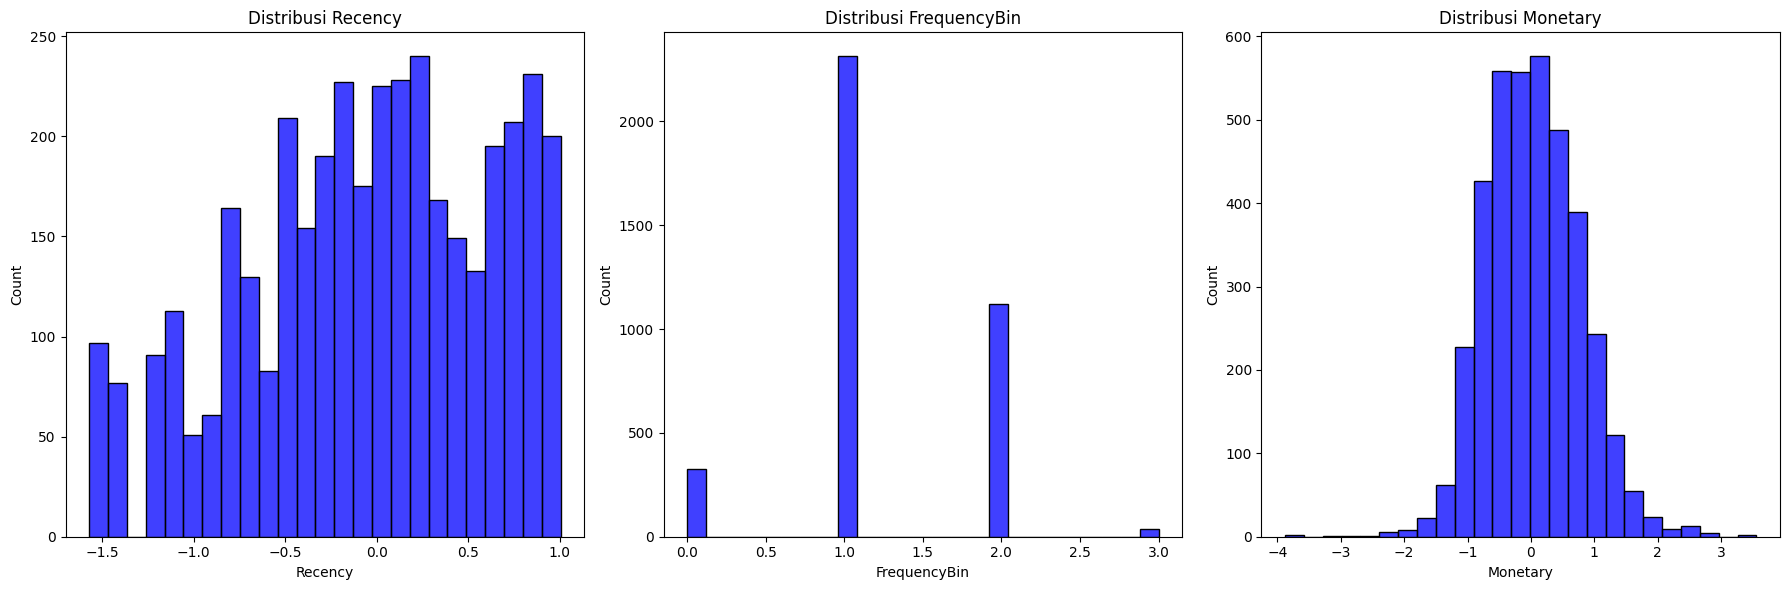

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, column in enumerate(bin_columns):
    sns.histplot(df_rfm_binned[column], bins=25, color='blue', ax=axes[i])
    axes[i].set_title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

# **Clustering**

## KMeans++

In [35]:
X_model = df_rfm_binned[bin_columns].values
kmeans = KMeans()

for n_clusters in range(3, 6):
    kmeans.set_params(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_model)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_model, labels)
    print(f'n_clusters = {n_clusters}, silhouette_score: {silhouette_avg}')

n_clusters = 3, silhouette_score: 0.4458439429540802
n_clusters = 4, silhouette_score: 0.3781605333321594
n_clusters = 5, silhouette_score: 0.3696200082208483


In [36]:
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10, max_iter=300)
kmeans.fit(X_model)
labels = kmeans.labels_

df_kmeans = df_rfm_clean.copy()
df_kmeans['Cluster'] = labels

def analyze_clusters(X, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        cluster_data = X[labels == cluster_id]

        mean_recency = cluster_data[:, 0].mean()
        mean_frequency = cluster_data[:, 1].mean()
        mean_monetary = cluster_data[:, 2].mean()

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata (mean) Recency: {mean_recency}")
        print(f"Rata-rata (mean) Frequency: {mean_frequency}")
        print(f"Rata-rata (mean) Monetary: {mean_monetary}")

analyze_clusters(X_model, labels, k)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: -0.45622182582222054
Rata-rata (mean) Frequency: 1.8725868725868726
Rata-rata (mean) Monetary: 0.5215310405859548

Cluster 2:
Rata-rata (mean) Recency: 0.29847175475899146
Rata-rata (mean) Frequency: 1.0298850574712644
Rata-rata (mean) Monetary: -0.4313339674623481

Cluster 3:
Rata-rata (mean) Recency: -0.7656999019946032
Rata-rata (mean) Frequency: 0.012195121951219513
Rata-rata (mean) Monetary: 1.1745956668934607

Silhouette Score: 0.4458439429540802


In [37]:
visual_3d = go.Scatter3d(
    x= df_kmeans['Recency'],
    y= df_kmeans['Frequency'],
    z= df_kmeans['Monetary'],
    mode='markers',
    marker=dict(
        color = df_kmeans['Cluster'],
        size= 20,
        line=dict(
            color= df_kmeans['Cluster'],
            width= 12
        ),
        opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D KMeans++',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

PCA KMeans++

In [38]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

kmeans_pca = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10, max_iter=300)
kmeans_pca.fit(df_PCA)

labels = kmeans_pca.predict(df_PCA)

score = silhouette_score(df_PCA, labels)
print("\nSilhouette Score:", score)


Silhouette Score: 0.5780582643099484


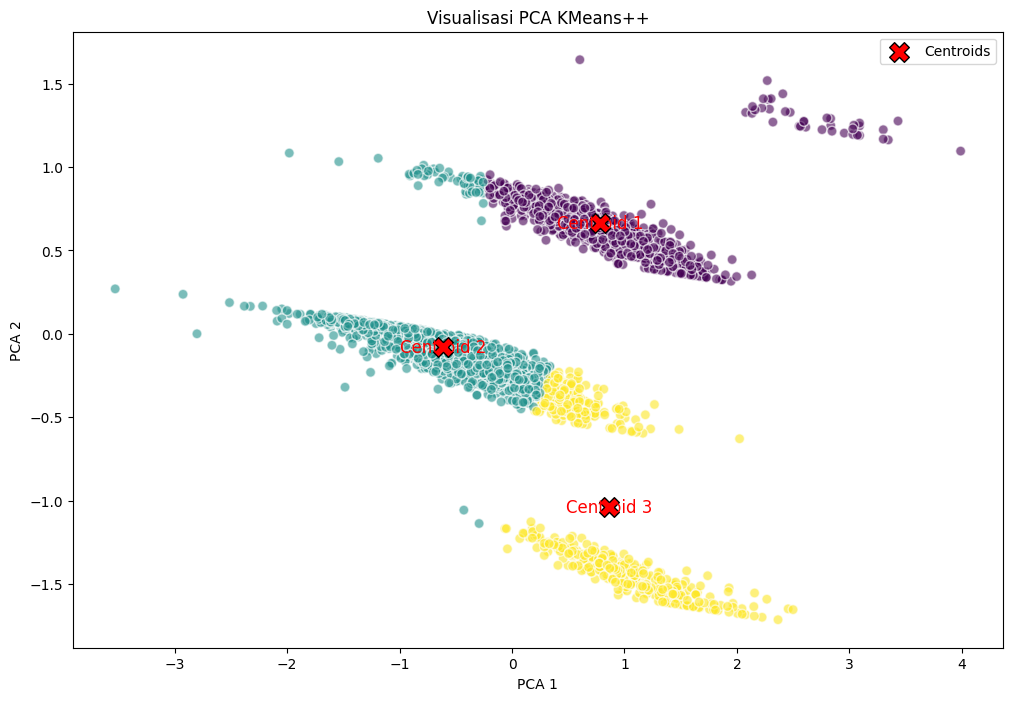


Nilai Centroids:
Centroid 1: PCA 1 = 0.79, PCA 2 = 0.66
Centroid 2: PCA 1 = -0.61, PCA 2 = -0.08
Centroid 3: PCA 1 = 0.86, PCA 2 = -1.04


In [39]:
centroids = kmeans_pca.cluster_centers_

plt.figure(figsize=(12, 8))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')

plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

plt.title('Visualisasi PCA KMeans++')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()

plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

## SPECTRAL

In [40]:
X_model = df_rfm_binned[bin_columns].values
spectral = SpectralClustering()

for n_clusters in range(3, 6):
    spectral.set_params(n_clusters=n_clusters)
    labels = spectral.fit_predict(X_model)
    silhouette_avg = silhouette_score(X_model, labels)
    print(f'n_clusters = {n_clusters}, silhouette_score: {silhouette_avg}')

n_clusters = 3, silhouette_score: 0.4427811809312985
n_clusters = 4, silhouette_score: 0.41755605151917113
n_clusters = 5, silhouette_score: 0.4086969051588653


In [41]:
s = 3
spectral = SpectralClustering(n_clusters=s)
spectral.fit(X_model)
labels = spectral.labels_

df_spectral = df_rfm_clean.copy()
df_spectral['Cluster'] = labels

def analyze_clusters(X, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        cluster_data = X[labels == cluster_id]

        mean_recency = cluster_data[:, 0].mean()
        mean_frequency = cluster_data[:, 1].mean()
        mean_monetary = cluster_data[:, 2].mean()

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata (mean) Recency: {mean_recency}")
        print(f"Rata-rata (mean) Frequency: {mean_frequency}")
        print(f"Rata-rata (mean) Monetary: {mean_monetary}")

analyze_clusters(X_model, labels, s)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: 0.2185799966021244
Rata-rata (mean) Frequency: 1.0347790507364976
Rata-rata (mean) Monetary: -0.358964823736204

Cluster 2:
Rata-rata (mean) Recency: -0.8492221411720875
Rata-rata (mean) Frequency: 0.003436426116838488
Rata-rata (mean) Monetary: 1.2309796330668805

Cluster 3:
Rata-rata (mean) Recency: -0.4514267491135595
Rata-rata (mean) Frequency: 2.0122295390404514
Rata-rata (mean) Monetary: 0.6035688175522856

Silhouette Score: 0.4427811809312985


In [42]:
visual_3d = go.Scatter3d(
    x= df_spectral['Recency'],
    y= df_spectral['Frequency'],
    z= df_spectral['Monetary'],
    mode='markers',
    marker=dict(
        color = df_spectral['Cluster'],
        size= 20,
        line=dict(
            color= df_spectral['Cluster'],
            width= 12
        ),
        opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D Spectral',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

PCA Spectral

In [43]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

spectral_pca = SpectralClustering(n_clusters=s)
spectral_pca.fit(X_model)
labels = spectral_pca.labels_

score = silhouette_score(df_PCA, labels)
print("\nSilhouette Score:", score)


Silhouette Score: 0.5571600455541279


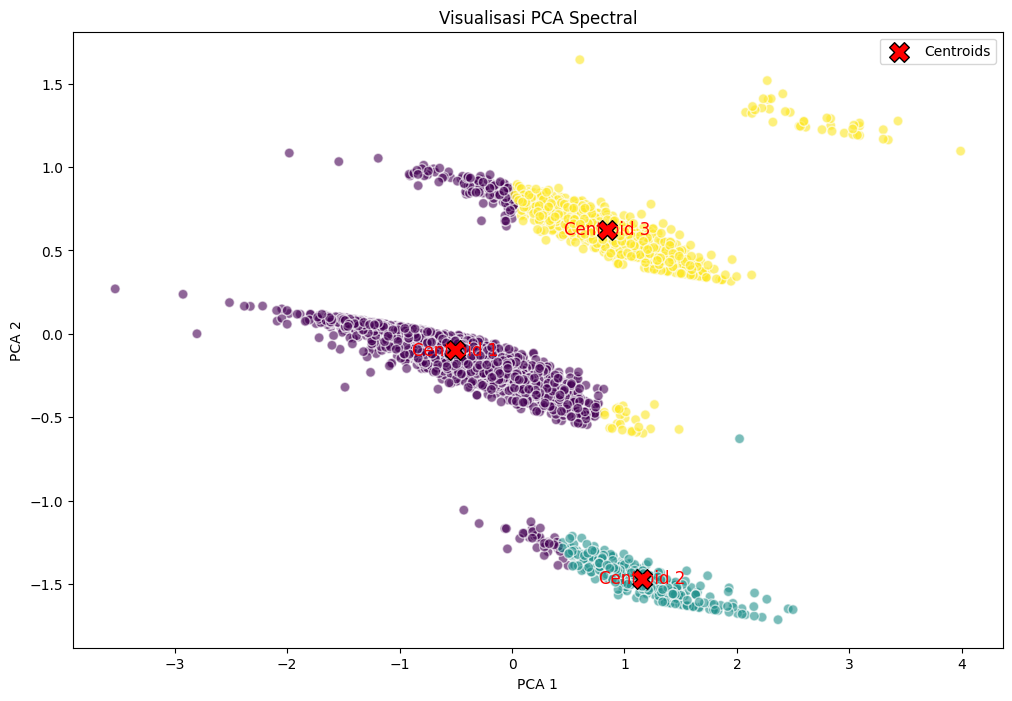


Nilai Centroids:
Centroid 1: PCA 1 = -0.50, PCA 2 = -0.10
Centroid 2: PCA 1 = 1.15, PCA 2 = -1.47
Centroid 3: PCA 1 = 0.84, PCA 2 = 0.62


In [44]:
plt.figure(figsize=(12, 8))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')

unique_labels = set(labels)
centroids_spectral = []

for i in unique_labels:
    sum_x = 0
    sum_y = 0
    count = 0

    for j in range(len(labels)):
        if labels[j] == i:
            sum_x += X_pca[j, 0]
            sum_y += X_pca[j, 1]
            count += 1

    centroid_x = sum_x / count
    centroid_y = sum_y / count

    centroids_spectral.append([centroid_x, centroid_y])

centroids_spectral = np.array(centroids_spectral)
plt.scatter(centroids_spectral[:, 0], centroids_spectral[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids_spectral):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

plt.title('Visualisasi PCA Spectral')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids_spectral):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

## GMM

In [45]:
X_model = df_rfm_binned[bin_columns].values
gmm = GaussianMixture()

for n_clusters in range(3, 6):
    gmm.set_params(n_components=n_clusters)
    gmm.fit(X_model)
    labels = gmm.predict(X_model)
    silhouette_avg = silhouette_score(X_model, labels)
    print(f'n_clusters = {n_clusters}, silhouette_score: {silhouette_avg}')

n_clusters = 3, silhouette_score: 0.44754959926985327
n_clusters = 4, silhouette_score: 0.33208592526991304
n_clusters = 5, silhouette_score: 0.4197881924081489


In [46]:
g = 3
gmm = GaussianMixture(n_components=g, random_state=42)
labels = gmm.fit_predict(X_model)

df_gmm = df_rfm_clean.copy()
df_gmm['Cluster'] = labels

def analyze_clusters(X, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        cluster_data = X[labels == cluster_id]

        mean_recency = cluster_data[:, 0].mean()
        mean_frequency = cluster_data[:, 1].mean()
        mean_monetary = cluster_data[:, 2].mean()

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata (mean) Recency: {mean_recency}")
        print(f"Rata-rata (mean) Frequency: {mean_frequency}")
        print(f"Rata-rata (mean) Monetary: {mean_monetary}")

analyze_clusters(X_model, labels, g)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: -0.34638343545215505
Rata-rata (mean) Frequency: 2.0327868852459017
Rata-rata (mean) Monetary: 0.5198096534495616

Cluster 2:
Rata-rata (mean) Recency: 0.19675527113334354
Rata-rata (mean) Frequency: 1.0
Rata-rata (mean) Monetary: -0.3720437206113381

Cluster 3:
Rata-rata (mean) Recency: -0.7558813071643403
Rata-rata (mean) Frequency: 0.0
Rata-rata (mean) Monetary: 1.1674123757522774

Silhouette Score: 0.44754959926985327


In [47]:
visual_3d = go.Scatter3d(
    x= df_gmm['Recency'],
    y= df_gmm['Frequency'],
    z= df_gmm['Monetary'],
    mode='markers',
    marker=dict(
        color = df_gmm['Cluster'],
        size= 20,
        line=dict(
            color= df_gmm['Cluster'],
            width= 12
        ),
        opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D GMM',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

PCA GMM

In [48]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

gmm_pca = GaussianMixture(n_components=g, random_state=42)
gmm_pca.fit(df_PCA)

labels = gmm_pca.predict(df_PCA)

score = silhouette_score(df_PCA, labels)
print("\nSilhouette Score:", score)


Silhouette Score: 0.5648761131097737


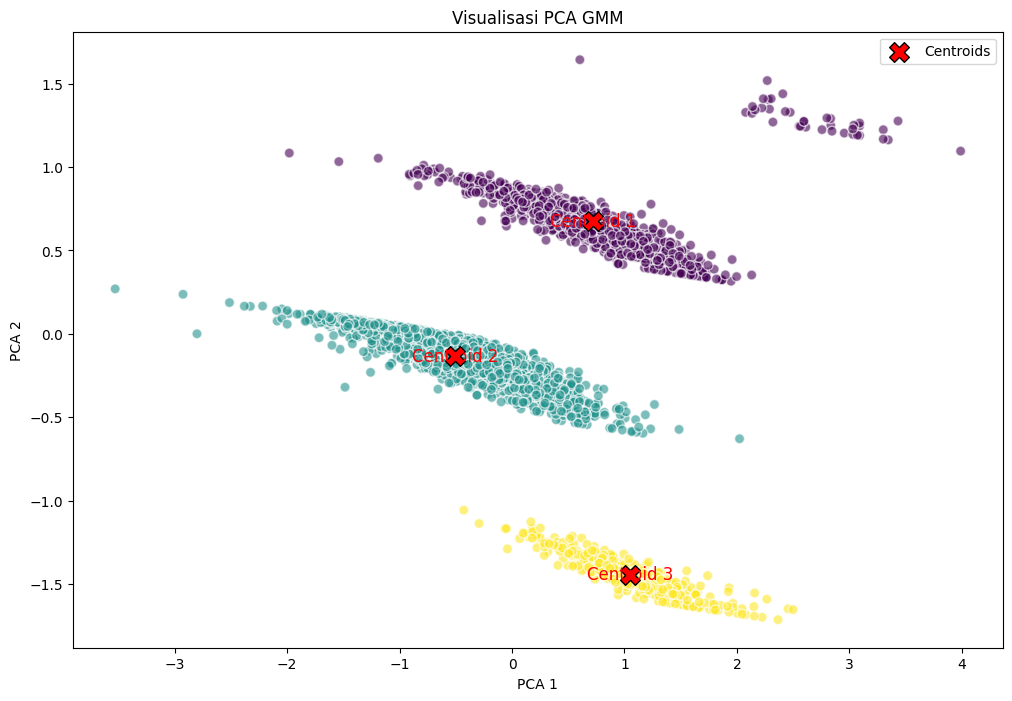


Nilai Centroids:
Centroid 1: PCA 1 = 0.72, PCA 2 = 0.67
Centroid 2: PCA 1 = -0.51, PCA 2 = -0.13
Centroid 3: PCA 1 = 1.05, PCA 2 = -1.44


In [49]:
centroids = gmm_pca.means_

plt.figure(figsize=(12, 8))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')

plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

plt.title('Visualisasi PCA GMM')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()

plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

## HDBSCAN

In [50]:
X_model = df_rfm_binned[bin_columns].values
hdb = HDBSCAN()

for n_clusters in range(3, 6):
    h = n_clusters
    hdb.set_params(min_cluster_size=h, min_samples=h)
    labels = hdb.fit_predict(X_model)
    silhouette_avg = silhouette_score(X_model, labels)
    print(f'n_clusters = {n_clusters}, silhouette_score: {silhouette_avg}')

n_clusters = 3, silhouette_score: 0.10814418993523015
n_clusters = 4, silhouette_score: -0.021283021848843786
n_clusters = 5, silhouette_score: 0.4406093786911833


In [51]:
h = 30
hdb = HDBSCAN(min_cluster_size=h, min_samples=h)

hdb.fit(X_model)
labels = hdb.labels_

df_hdb = df_rfm_clean.copy()
df_hdb['Cluster'] = labels

def analyze_clusters(X, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        cluster_data = X[labels == cluster_id]

        mean_recency = cluster_data[:, 0].mean()
        mean_frequency = cluster_data[:, 1].mean()
        mean_monetary = cluster_data[:, 2].mean()

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata (mean) Recency: {mean_recency}")
        print(f"Rata-rata (mean) Frequency: {mean_frequency}")
        print(f"Rata-rata (mean) Monetary: {mean_monetary}")

analyze_clusters(X_model, labels, 3)

score = silhouette_score(X_model, labels)
print("\nSilhouette Score:", score)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: -0.7534123447572297
Rata-rata (mean) Frequency: 0.0
Rata-rata (mean) Monetary: 1.148338075767049

Cluster 2:
Rata-rata (mean) Recency: -0.3194268146695652
Rata-rata (mean) Frequency: 2.0
Rata-rata (mean) Monetary: 0.46899179040875416

Cluster 3:
Rata-rata (mean) Recency: 0.19801698495802217
Rata-rata (mean) Frequency: 1.0
Rata-rata (mean) Monetary: -0.36597401527473467

Silhouette Score: 0.441261685884261


In [52]:
visual_3d = go.Scatter3d(
    x= df_hdb['Recency'],
    y= df_hdb['Frequency'],
    z= df_hdb['Monetary'],
    mode='markers',
    marker=dict(
        color = df_hdb['Cluster'],
        size= 20,
        line=dict(
            color= df_hdb['Cluster'],
            width= 12
        ),
        opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Visualisasi 3D HDBSCAN',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

PCA HDBCSAN

In [53]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

hdb_pca = HDBSCAN(min_cluster_size=h, min_samples=h)
hdb_pca.fit(X_model)
labels = hdb_pca.labels_

score = silhouette_score(df_PCA, labels)
print("\nSilhouette Score:", score)


Silhouette Score: 0.5616086332057942


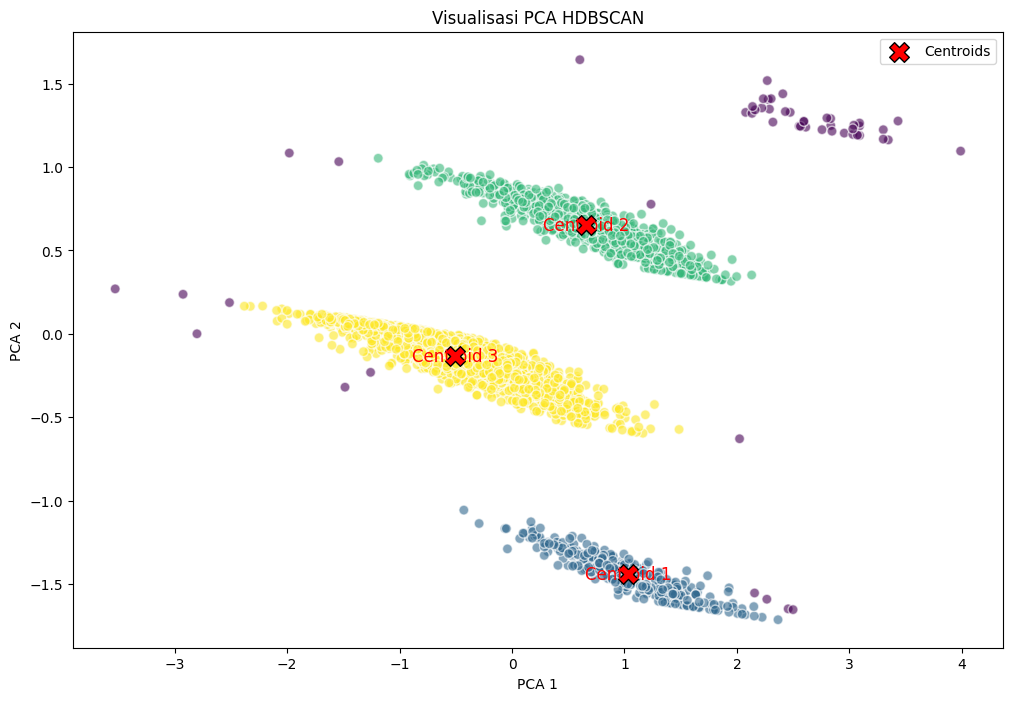


Nilai Centroids:
Centroid 1: PCA 1 = 1.03, PCA 2 = -1.44
Centroid 2: PCA 1 = 0.66, PCA 2 = 0.65
Centroid 3: PCA 1 = -0.50, PCA 2 = -0.13


In [54]:
plt.figure(figsize=(12, 8))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')

unique_labels = set(labels)
unique_labels.discard(-1)
centroids_spectral = []

for i in unique_labels:
    sum_x = 0
    sum_y = 0
    count = 0

    for j in range(len(labels)):
        if labels[j] == i:
            sum_x += X_pca[j, 0]
            sum_y += X_pca[j, 1]
            count += 1

    centroid_x = sum_x / count
    centroid_y = sum_y / count

    centroids_spectral.append([centroid_x, centroid_y])

centroids_spectral = np.array(centroids_spectral)
plt.scatter(centroids_spectral[:, 0], centroids_spectral[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids_spectral):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

plt.title('Visualisasi PCA HDBSCAN')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids_spectral):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

### Cluster Analysis

In [55]:
df_hdb = df_hdb[df_hdb['Cluster'] != -1]
df_hdb.describe(include='all')

,CustomerID,Recency,Frequency,Monetary,Cluster
count,3746.000000,3746.000000,3746.000000,3746.000000,3746.000000
mean,15552.168980,83.520555,4.215964,1258.900004,1.529632
std,1570.689639,89.090190,4.678054,2035.007788,0.648962
min,12747.000000,1.000000,1.000000,12.750000,0.000000
25%,14205.250000,17.000000,1.000000,283.530000,1.000000
50%,15553.500000,46.000000,2.500000,613.980000,2.000000
75%,16904.750000,126.750000,5.000000,1452.717500,2.000000
max,18287.000000,340.000000,35.000000,33285.810000,2.000000


In [56]:
cluster_analysis = df_hdb.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_scaled)) * 100)
).reset_index().sort_values(by='Cluster')

cluster_analysis

,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
0,0,16.633540,16.574534,5252.739224,322,8.478146
1,1,42.863148,5.892665,1720.508632,1118,29.436546
2,2,112.571986,1.677363,477.419225,2306,60.716166


In [57]:
def label_cluster(row):
    if row['Avg_Recency'] > cluster_analysis['Avg_Recency'].median():
       label_recency = 'High'
    else: label_recency = 'Low'

    if row['Avg_Frequency'] > cluster_analysis['Avg_Frequency'].median():
       label_frequency = 'High'
    else: label_frequency = 'Low'

    if row['Avg_Monetary'] > cluster_analysis['Avg_Monetary'].median():
       label_monetary = 'High'
    else: label_monetary = 'Low'

    if label_recency == 'Low' and label_frequency == 'High' and label_monetary == 'High':
        return 'Loyal Customers'
    elif label_recency == 'Low':
        return 'New Customers / Low Spenders'
    else: return 'Churns / One Time Spenders'

cluster_analysis['Label'] = cluster_analysis.apply(label_cluster, axis=1)
cluster_analysis

,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage,Label
0,0,16.633540,16.574534,5252.739224,322,8.478146,Loyal Customers
1,1,42.863148,5.892665,1720.508632,1118,29.436546,New Customers / Low Spenders
2,2,112.571986,1.677363,477.419225,2306,60.716166,Churns / One Time Spenders


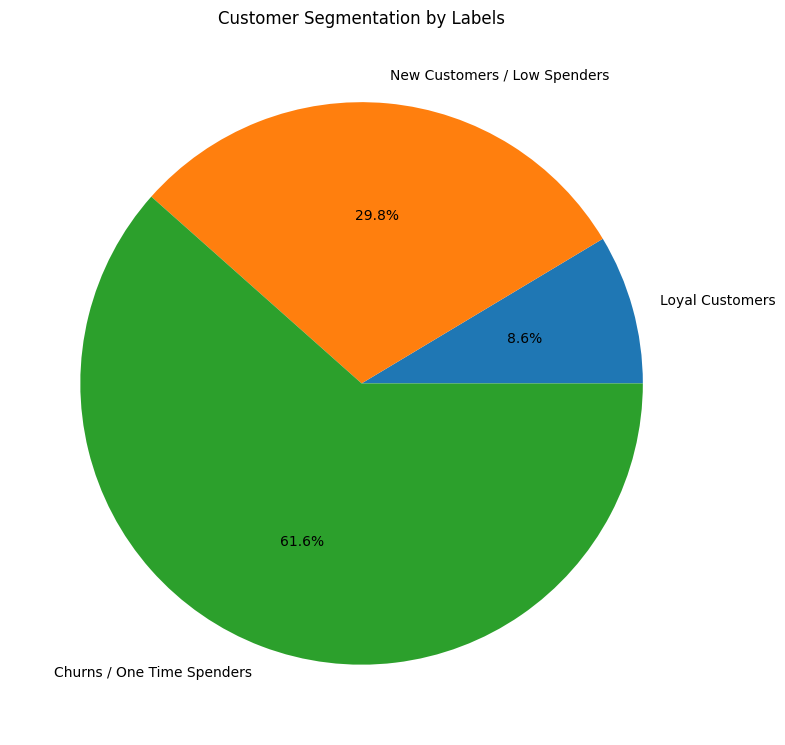

In [58]:
values = cluster_analysis['Percentage']
labels = cluster_analysis['Label']

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Customer Segmentation by Labels')
plt.tight_layout()
plt.show()

# **Intepretasi Hasil Clustering**

In [59]:
df_hdb.groupby('Cluster')[columns].agg(['mean', 'min', 'max'])

Recency           Frequency             Monetary                  
               mean min  max       mean min max         mean     min       max
Cluster                                                                       
0         16.633540   1  180  16.574534  11  35  5252.739224  573.45  33285.81
1         42.863148   1  330   5.892665   4  10  1720.508632   99.94  12650.08
2        112.571986   1  340   1.677363   1   3   477.419225   12.75   6748.80

## Karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 1: (Customer dengan nilai )**
- **Rata-rata (mean) Recency:16.633540**
- **Rata-rata (mean) Frequency:16.574534**
- **Rata-rata (mean) Monetary:5252.739224**
- **Analisis: customer yang termasuk di cluster ini cenderung memiliki loyalitas tinggi dengan monetary yang tinggi mereka mereka juga masih sering berbelanja. pelanggan dalam cluster ini sebaiknya diberikan prioritas VIP karena berdampak besar terhadap penjualan. Contoh program yang dapat diterapkan adalah membership karena pelanggan akan datang untuk mendapatkan benefit dari membership**

2. **Cluster 2: (Customer dengan nilai )**
- **Rata-rata (mean) Recency:42.863148**
- **Rata-rata (mean) Frequency:5.892665**
- **Rata-rata (mean) Monetary:1720.508632**
- **Analisis:customer pada cluster ini memiliki nilai RFM yang berada di tengah,mereka masih bertransaksi tetapi tidak berdampak besar terhadap penjualan. pelanggan dalam cluster ini sebainya diberikan promo yang menarik untuk meningkatkan jumlah transaksi. berikan rekomendasi produk berkaitan dengan produk yang pernah dibeli pelanggan. **

3. **Cluster 3: (Customer dengan nilai )**
- **Rata-rata (mean) Recency:112.571986**
- **Rata-rata (mean) Frequency:1.677363**
- **Rata-rata (mean) Monetary:477.419225**
- **Analisis:bereikan promosi yang menarik agar mereka bertransaksi kembali contohnya dengan memberikan diskon yang besar. jika dirasa tidak efisien, sebaiknya dianggap churn karena tidak berdampak besar terhadap penjualan. **


# **Post-processing**

In [60]:
cluster_to_label = cluster_analysis['Label'].to_dict()

df_hdb['Label'] = df_hdb['Cluster'].map(cluster_to_label)

df_hdb.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Label
1,12747.0,2,9,3489.74,1,New Customers / Low Spenders
3,12749.0,4,8,3868.20,1,New Customers / Low Spenders
4,12820.0,3,4,942.34,1,New Customers / Low Spenders
5,12821.0,214,1,92.72,2,Churns / One Time Spenders
6,12822.0,71,3,918.98,2,Churns / One Time Spenders


In [61]:
df_final = df.copy()
df_final = df_final.merge(
    df_hdb[['CustomerID', 'Cluster', 'Label']],
    on='CustomerID',
    how='inner'
).reset_index()

df_final

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,category,Sales,Cluster,Label
0,0,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom,bags,19.50,1,New Customers / Low Spenders
1,1,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,stationery,10.50,1,New Customers / Low Spenders
2,2,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,stationery,10.50,1,New Customers / Low Spenders
3,3,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom,bags,10.50,1,New Customers / Low Spenders
4,4,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom,bags,12.50,1,New Customers / Low Spenders
...,...,...,...,...,...,...,...,...,...,...,...,...,...
293387,293387,581585,21684,SMALL MEDINA STAMPED METAL BOWL,12,2011-12-09 12:31:00,0.85,15804.0,United Kingdom,kitchen,10.20,0,Loyal Customers
293388,293388,581585,22398,MAGNETS PACK OF 4 SWALLOWS,12,2011-12-09 12:31:00,0.39,15804.0,United Kingdom,others,4.68,0,Loyal Customers
293389,293389,581585,23328,SET 6 SCHOOL MILK BOTTLES IN CRATE,4,2011-12-09 12:31:00,3.75,15804.0,United Kingdom,kitchen,15.00,0,Loyal Customers
293390,293390,581585,23145,ZINC T-LIGHT HOLDER STAR LARGE,12,2011-12-09 12:31:00,0.95,15804.0,United Kingdom,lighting,11.40,0,Loyal Customers


In [62]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293392 entries, 0 to 293391
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   index        293392 non-null  int64         
 1   InvoiceNo    293392 non-null  object        
 2   StockCode    293392 non-null  object        
 3   Description  293392 non-null  object        
 4   Quantity     293392 non-null  int64         
 5   InvoiceDate  293392 non-null  datetime64[ns]
 6   UnitPrice    293392 non-null  float64       
 7   CustomerID   293392 non-null  float64       
 8   Country      293392 non-null  object        
 9   category     293392 non-null  object        
 10  Sales        293392 non-null  float64       
 11  Cluster      293392 non-null  int64         
 12  Label        293392 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(3), object(6)
memory usage: 29.1+ MB


In [63]:
df_final.describe(include='all')

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,category,Sales,Cluster,Label
count,293392.000000,293392.0,293392,293392,293392.000000,293392,293392.000000,293392.000000,293392,293392,293392.000000,293392.000000,293392
unique,NaN,15793.0,3553,3727,NaN,NaN,NaN,NaN,1,13,NaN,NaN,3
top,NaN,567183.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,decoration,NaN,NaN,New Customers / Low Spenders
freq,NaN,392.0,1620,1615,NaN,NaN,NaN,NaN,293392,72799,NaN,NaN,125853
mean,146695.500000,NaN,NaN,NaN,9.918024,2011-07-25 13:43:51.902233088,3.091881,15569.387308,NaN,NaN,16.073511,0.962790,NaN
min,0.000000,NaN,NaN,NaN,-1515.000000,2011-01-04 10:00:00,0.000000,12747.000000,NaN,NaN,-38970.000000,0.000000,NaN
25%,73347.750000,NaN,NaN,NaN,2.000000,2011-05-03 11:22:00,1.250000,14292.000000,NaN,NaN,4.200000,0.000000,NaN
50%,146695.500000,NaN,NaN,NaN,4.000000,2011-08-15 09:57:00,1.850000,15555.000000,NaN,NaN,10.200000,1.000000,NaN
75%,220043.250000,NaN,NaN,NaN,12.000000,2011-10-25 13:53:00,3.750000,16903.000000,NaN,NaN,17.700000,2.000000,NaN
max,293391.000000,NaN,NaN,NaN,4300.000000,2011-12-09 12:31:00,38970.000000,18287.000000,NaN,NaN,38970.000000,2.000000,NaN


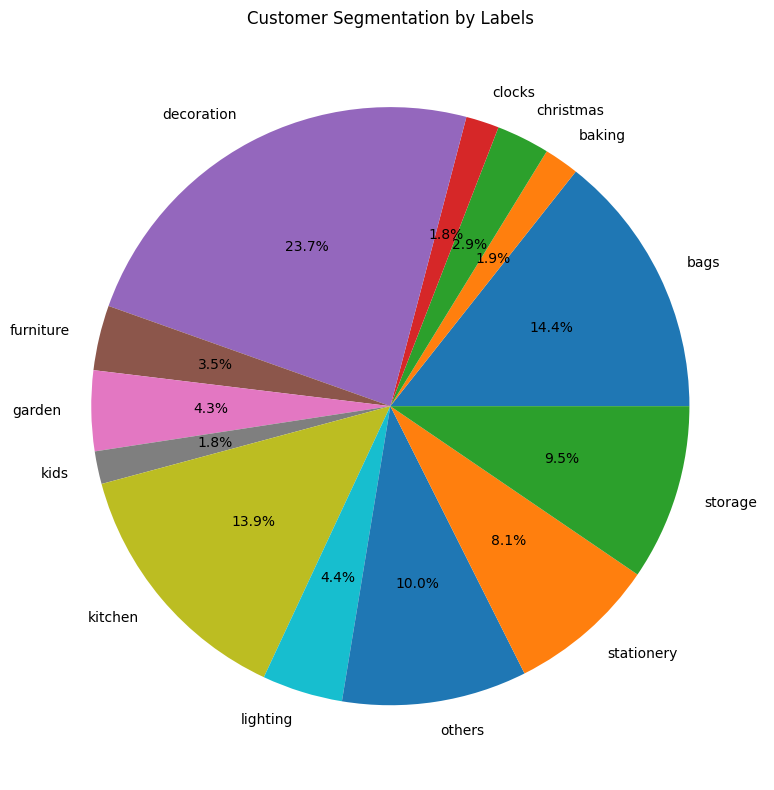

,category,jumlah,persentase
0,bags,12809,0.143554
1,baking,1680,0.018828
2,christmas,2565,0.028747
3,clocks,1599,0.017920
4,decoration,21109,0.236574
5,furniture,3137,0.035157
6,garden,3873,0.043406
7,kids,1580,0.017707
8,kitchen,12368,0.138611
9,lighting,3891,0.043607


In [104]:
df_final[df_final['Cluster'] == 0]
df_final0=df_final[df_final['Cluster'] == 0].groupby('category').size().reset_index(name='jumlah')

total = df_final0['jumlah'].sum()
df_final0['persentase'] = df_final0['jumlah']/total
values = df_final0['persentase']
labels = df_final0['category']

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Customer Segmentation by Labels')
plt.tight_layout()
plt.show()

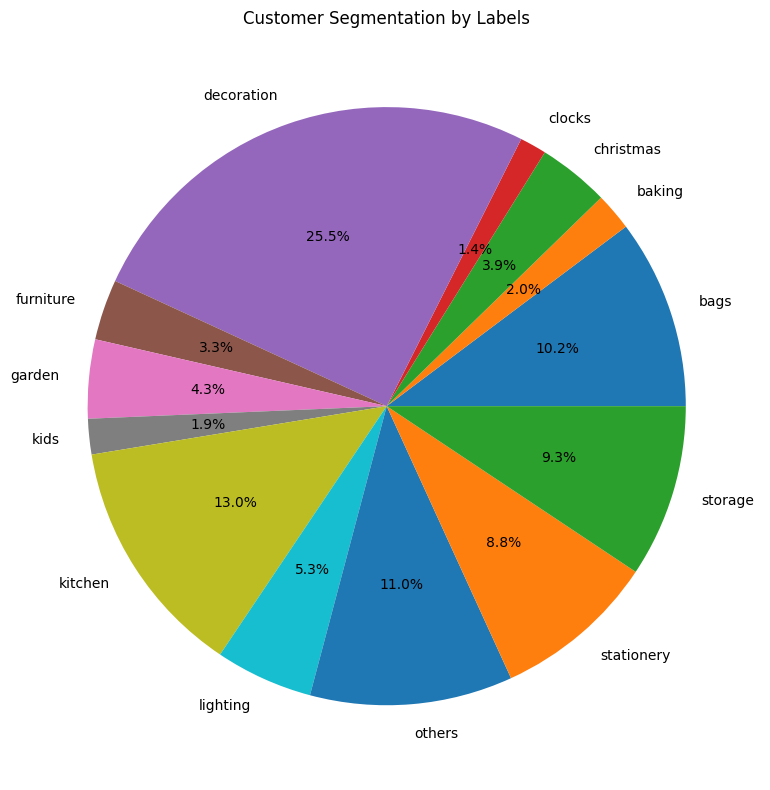

In [107]:
df_final[df_final['Cluster'] == 1]
df_final1=df_final[df_final['Cluster'] == 1].groupby('category').size().reset_index(name='jumlah')

total = df_final1['jumlah'].sum()
df_final1['persentase'] = df_final1['jumlah']/total
values = df_final1['persentase']
labels = df_final1['category']

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Customer Segmentation by Labels')
plt.tight_layout()
plt.show()

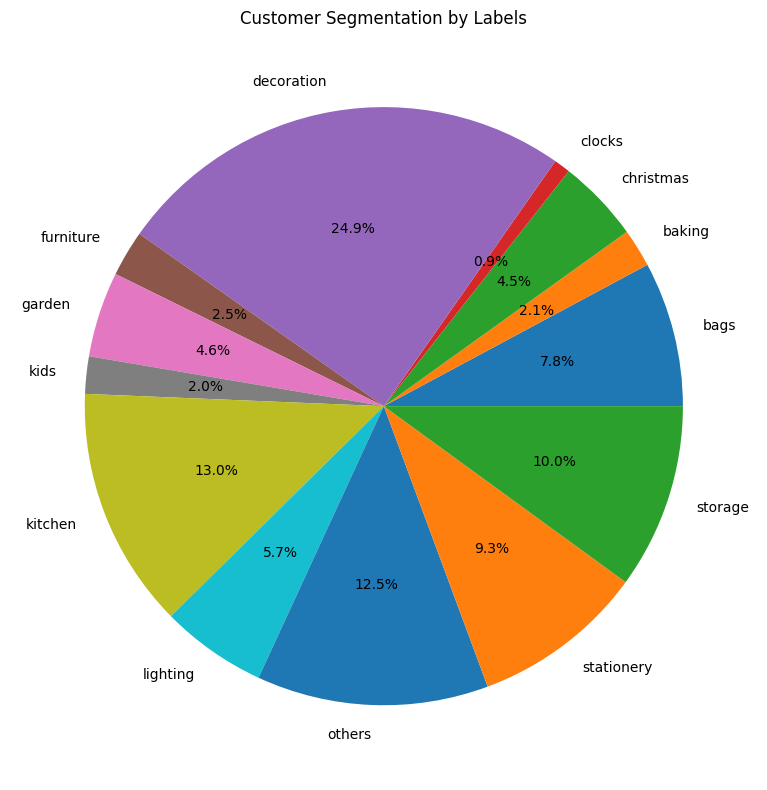

In [108]:
df_final[df_final['Cluster'] == 2]
df_final2=df_final[df_final['Cluster'] == 2].groupby('category').size().reset_index(name='jumlah')

total = df_final2['jumlah'].sum()
df_final2['persentase'] = df_final2['jumlah']/total
values = df_final2['persentase']
labels = df_final2['category']

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Customer Segmentation by Labels')
plt.tight_layout()
plt.show()

In [67]:
df_final.to_csv('online_retail_uci_clustering.csv', index=False)

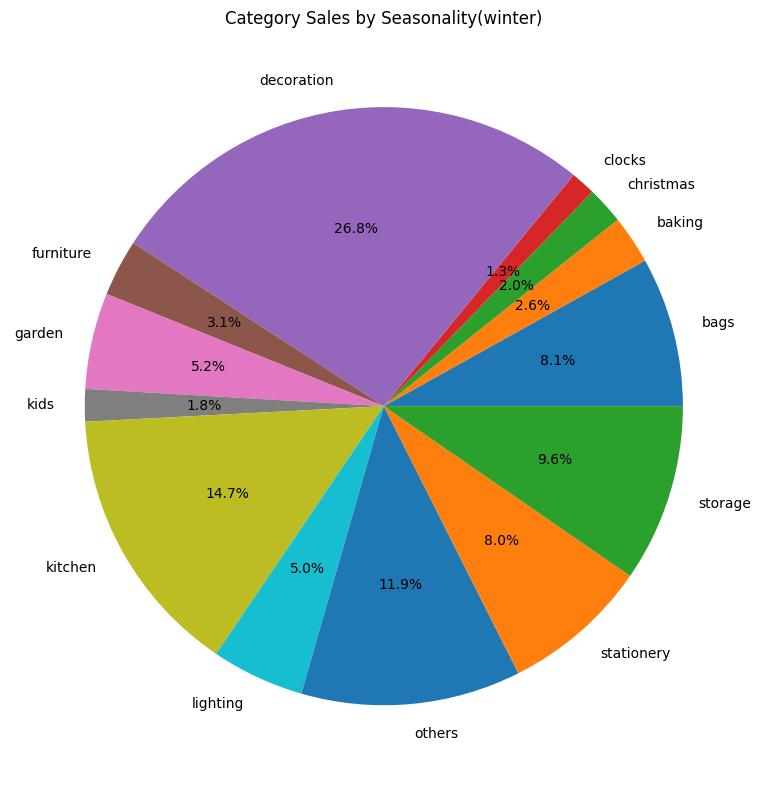

In [129]:
df_final_winter = df_final[(df_final['InvoiceDate'].dt.month >=12) | (df_final['InvoiceDate'].dt.month <=2) ]
df_final_winter
df_final_winter =df_final_winter.groupby('category').size().reset_index(name='jumlah')

total = df_final_winter['jumlah'].sum()
df_final_winter['persentase'] = df_final_winter['jumlah']/total
values = df_final_winter['persentase']
labels = df_final_winter['category']

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Category Sales by Seasonality(Winter)')
plt.tight_layout()
plt.show()

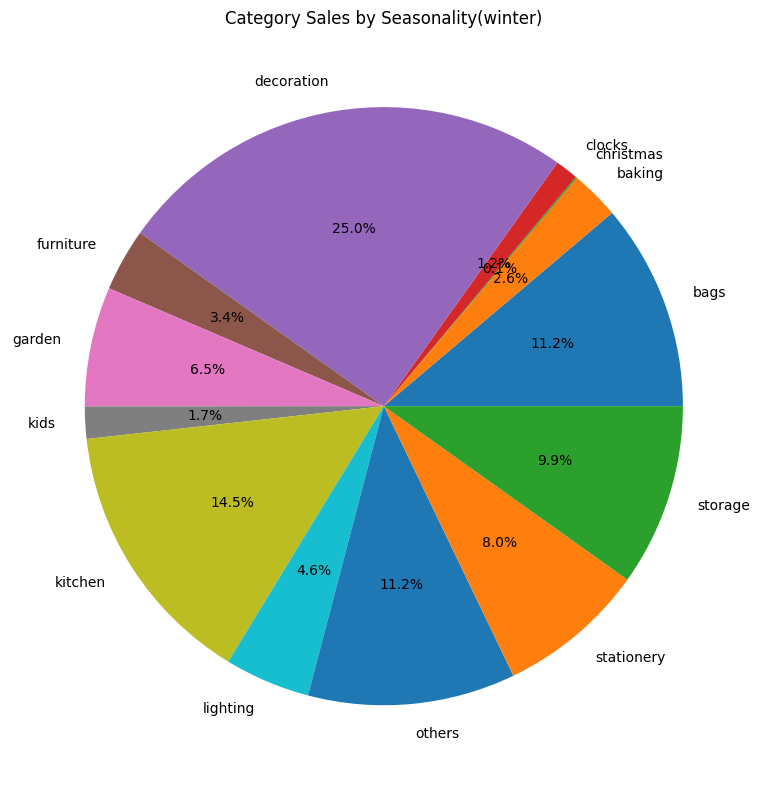

In [130]:
df_final_spring = df_final[(df_final['InvoiceDate'].dt.month >=3) & (df_final['InvoiceDate'].dt.month <=5)]
df_final_spring =df_final_spring.groupby('category').size().reset_index(name='jumlah')

total = df_final_spring['jumlah'].sum()
df_final_spring['persentase'] = df_final_spring['jumlah']/total
values = df_final_spring['persentase']
labels = df_final_spring['category']

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Category Sales by Seasonality(Spring)')
plt.tight_layout()
plt.show()

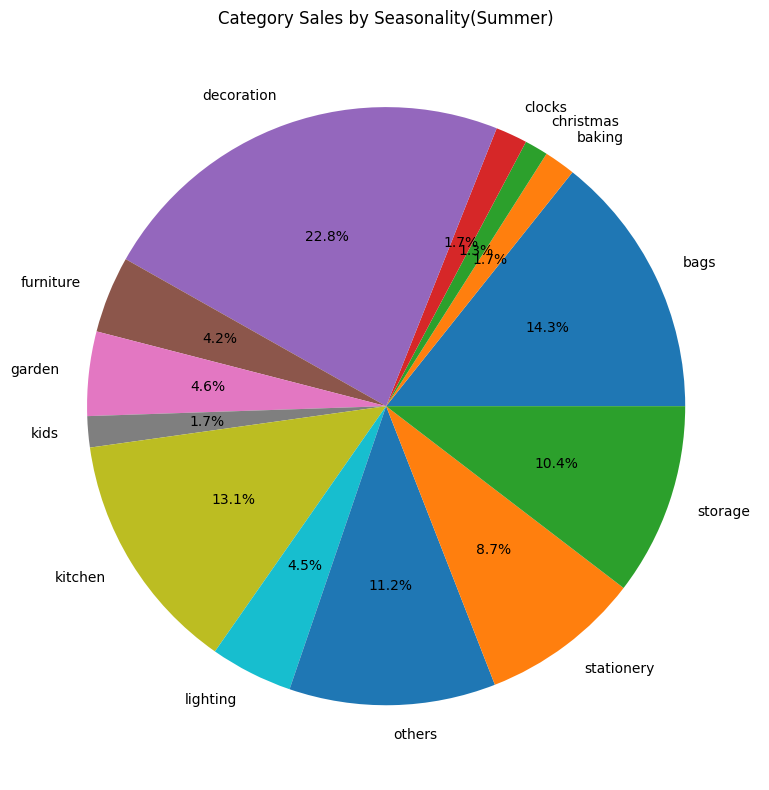

In [132]:
df_final_summer = df_final[(df_final['InvoiceDate'].dt.month >=6) & (df_final['InvoiceDate'].dt.month <=8)]
df_final_summer =df_final_summer.groupby('category').size().reset_index(name='jumlah')

total = df_final_summer['jumlah'].sum()
df_final_summer['persentase'] = df_final_summer['jumlah']/total
values = df_final_summer['persentase']
labels = df_final_summer['category']

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Category Sales by Seasonality(Summer)')
plt.tight_layout()
plt.show()

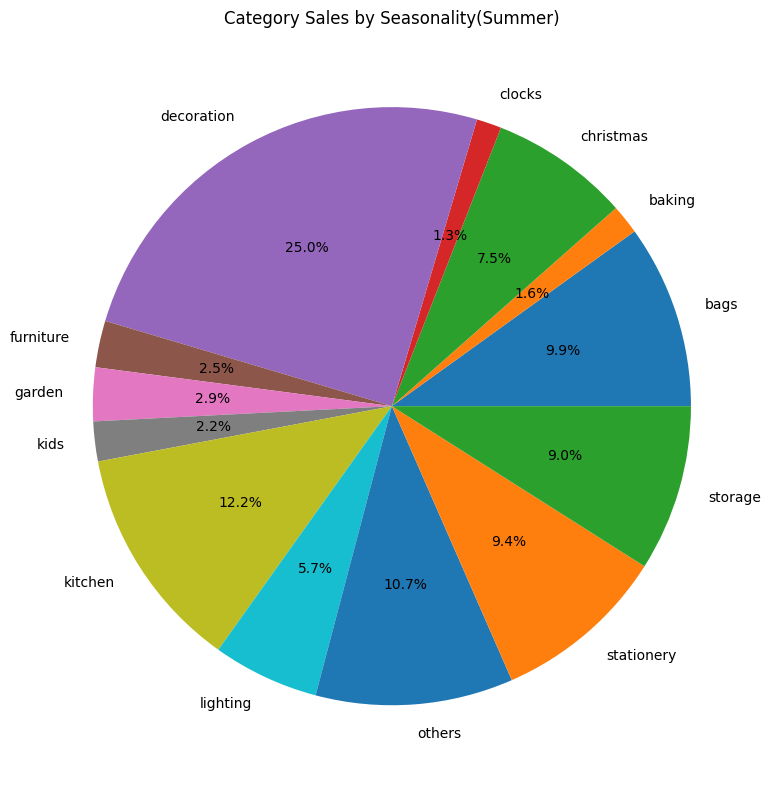

In [133]:
df_final_fall = df_final[(df_final['InvoiceDate'].dt.month >=9) & (df_final['InvoiceDate'].dt.month <=11)]
df_final_fall =df_final_fall.groupby('category').size().reset_index(name='jumlah')

total = df_final_fall['jumlah'].sum()
df_final_fall['persentase'] = df_final_fall['jumlah']/total
values = df_final_fall['persentase']
labels = df_final_fall['category']

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Category Sales by Seasonality(Summer)')
plt.tight_layout()
plt.show()

End of Code.